In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [4]:
def import_data(file_path):
    data = np.loadtxt(file_path)
    return data

In [5]:
def assign_labels(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

In [6]:
def fit_kmeans(X, k, max_iters=100):
    centroids = X[np.random.choice(len(X), size=k, replace=False)]
    
    for _ in range(max_iters):
        closest_centroids = assign_labels(X, centroids)
        
        new_centroids = []
        for i in range(k):
            points_in_cluster = X[closest_centroids == i]
            if len(points_in_cluster) > 0:
                new_centroids.append(points_in_cluster.mean(axis=0))
            else:
                new_centroids.append(X[np.random.choice(len(X))])
                
        new_centroids = np.array(new_centroids)
        
        if np.allclose(centroids, new_centroids, atol=1e-6):
            break
        centroids = new_centroids
        
    return centroids, closest_centroids

In [7]:
def fit_spectral(X, k, gamma=1.0):
    n_samples = X.shape[0]
    
    sq_norms = np.sum(X**2, axis=1, keepdims=True)

    sq_dists = sq_norms - 2 * (X @ X.T) + sq_norms.T
    sq_dists = np.maximum(sq_dists, 0)

    A = np.exp(-gamma * sq_dists)
    np.fill_diagonal(A, 0)
    
    D_diag = np.sum(A, axis=1)
    

    D_inv_sqrt = 1.0 / np.sqrt(np.clip(D_diag, 1e-10, None))
    D_inv_sqrt_mat = np.diag(D_inv_sqrt)
    L_sym = np.eye(n_samples) - D_inv_sqrt_mat @ A @ D_inv_sqrt_mat
    
    eigenvalues, eigenvectors = np.linalg.eigh(L_sym)
    
    X_spectral = eigenvectors[:, :k]
    
    rows_norm = np.linalg.norm(X_spectral, axis=1, keepdims=True)
    X_spectral = X_spectral / np.clip(rows_norm, 1e-10, None)
    
    _, labels = fit_kmeans(X_spectral, k)
    
    return labels

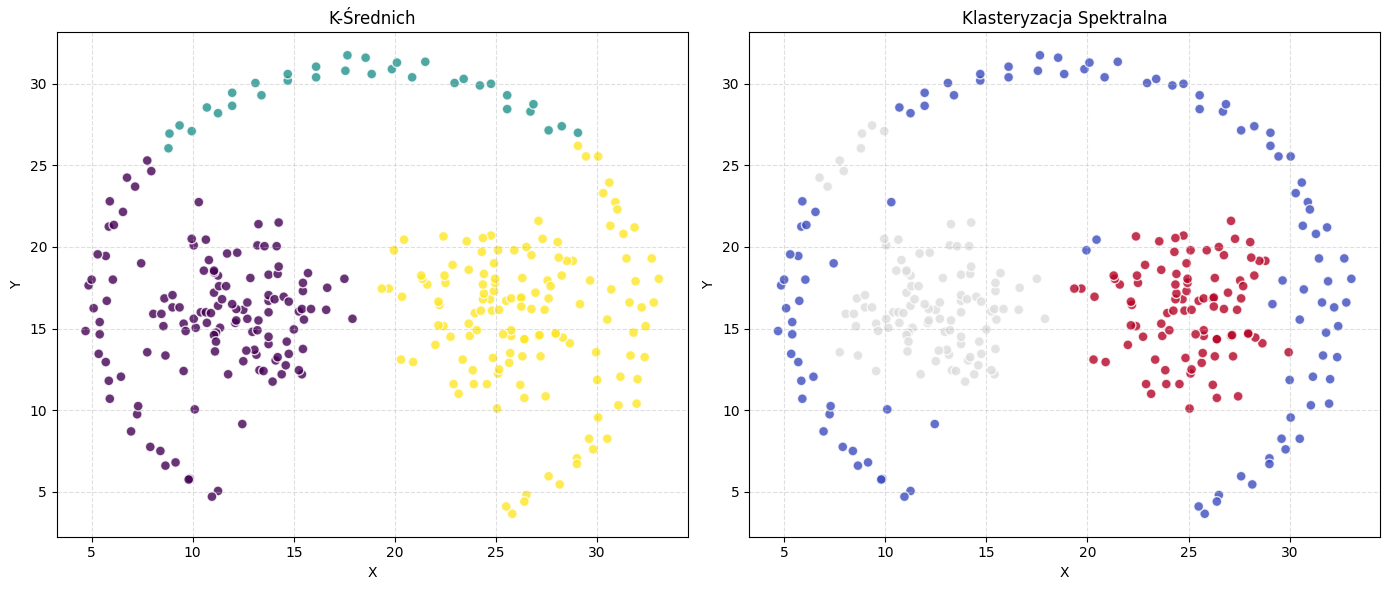

In [ ]:
path = 'dane_2D_3'

X_train = import_data(f'dane/{path}.txt')

k = 3
gamma = 10.0 #


_, kmeans_labels = fit_kmeans(X_train, k)
spectral_labels = fit_spectral(X_train, k, gamma=gamma)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


scatter1 = ax1.scatter(X_train[:, 0], X_train[:, 1], c=kmeans_labels, cmap='viridis', s=50, edgecolors='white', alpha=0.8)
ax1.set_title("K-Średnich")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.grid(True, linestyle="--", alpha=0.4)


scatter2 = ax2.scatter(X_train[:, 0], X_train[:, 1], c=spectral_labels, cmap='coolwarm', s=50, edgecolors='white', alpha=0.8)
ax2.set_title("Klasteryzacja Spektralna")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.grid(True, linestyle="--", alpha=0.4)


plt.tight_layout()
plt.savefig(f'{path}_spectral.png', dpi=300)
plt.show()

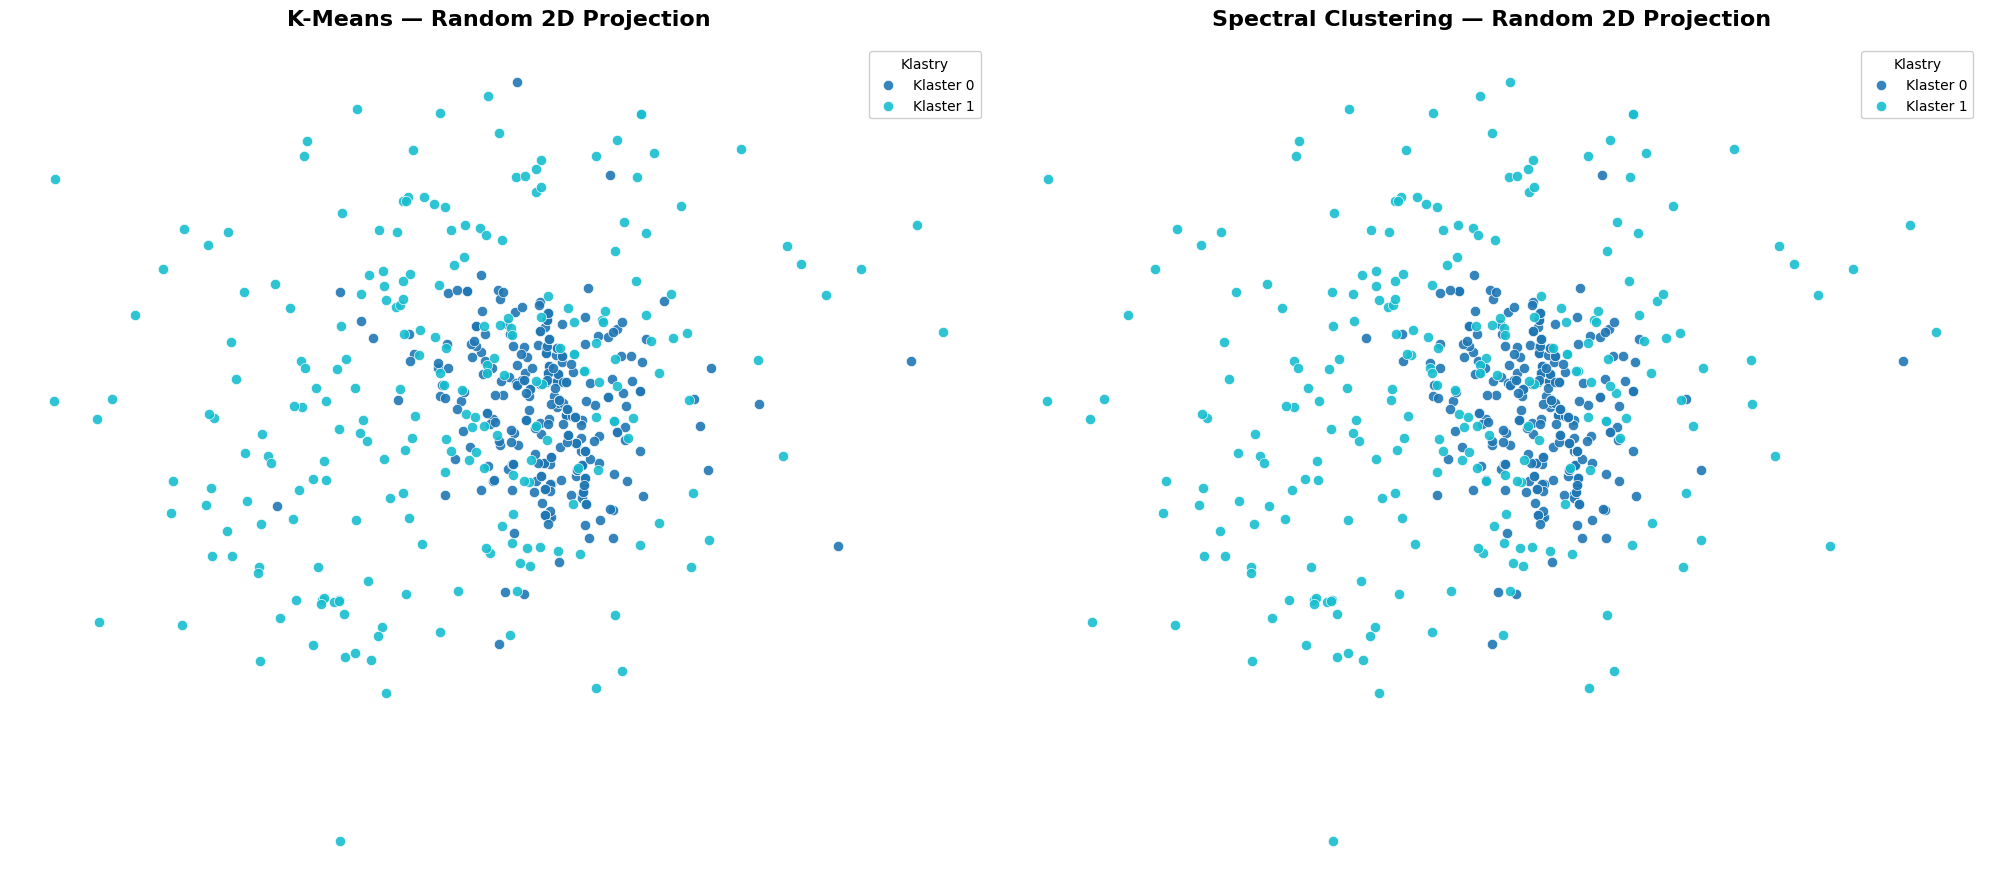

In [ ]:
path = 'data_18D'
X_train = import_data(f'dane/rp.data')
X_train = np.array(X_train)

k = 2
gamma = 0.1

_, kmeans_labels = fit_kmeans(X_train, k)
spectral_labels = fit_spectral(X_train, k, gamma=gamma)

# rng = np.random.default_rng() 
# random_matrix = rng.normal(size=(X_train.shape[1], 2))

embedding = PCA(n_components=2).fit_transform(X_train)
# embedding = X_train @ random_matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
cmap = plt.get_cmap("tab10", k)
for i in range(k):
    pts = embedding[kmeans_labels == i]
    
    if len(pts) > 0:
        ax1.scatter(
            pts[:, 0],
            pts[:, 1],
            s=55,
            color=cmap(i),
            alpha=0.9,
            edgecolors='white',
            linewidths=0.5,
            label=f"Klaster {i}"
        )

ax1.set_title("K-Means — Random 2D Projection", fontsize=16, weight='bold', pad=14)
ax1.set_xticks([])
ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.legend(frameon=True, fancybox=True, framealpha=0.95, title="Klastry")

for i in range(k):
    pts_spectral = embedding[spectral_labels == i]
    if len(pts_spectral) > 0:
        ax2.scatter(
            pts_spectral[:, 0],
            pts_spectral[:, 1],
            s=55,
            color=cmap(i),
            alpha=0.9,
            edgecolors='white',
            linewidths=0.5,
            label=f"Klaster {i}"
        )

ax2.set_title("Spectral Clustering — Random 2D Projection", fontsize=16, weight='bold', pad=14)
ax2.set_xticks([])
ax2.set_yticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.legend(frameon=True, fancybox=True, framealpha=0.95, title="Klastry")

plt.tight_layout()
plt.savefig(f'{path}_comparison_random_project.png', dpi=300, bbox_inches="tight")
plt.show()